# PyTorch Neural Network Development

This notebook develops the networks that we will use in PyTorch.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


##  Create a neural network with a configurable number of inputs and hidden layers 

In [2]:
class TanhNet(nn.Module):
    def __init__(self, n_inputs=2, n_hidden=3):
        super(TanhNet, self).__init__()
        self.fc1 = nn.Linear(n_inputs, n_hidden)
        self.fc2 = nn.Linear(n_hidden, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = F.tanh(x)
        x = self.fc2(x)
        output = x
        return output

class ReluNet(nn.Module):
    def __init__(self, n_inputs=2, n_hidden=3):
        super(ReluNet, self).__init__()
        self.fc1 = nn.Linear(n_inputs, n_hidden)
        self.fc2 = nn.Linear(n_hidden, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        output = x
        return output

class FFNN():
    """General FFNN Class"""

    def __init__(
            self, net_type='tanh',
            n_inputs=2, n_hidden=3,
            lr=0.001, momentum=0.9,
            use_gpu=True):
        """Initializes the FFNN wrapper class"""
        
        # Grad the training device indicator
        self.use_gpu = use_gpu

        # Initialize the network
        if net_type == 'tanh':
            self.net = TanhNet(n_inputs=n_inputs, n_hidden=n_hidden)
        else:
            self.net = ReluNet(n_inputs=n_inputs, n_hidden=n_hidden)

        # If using GPU and GPU is available set device to GPU
        if use_gpu:
            self.device = torch.device(
                "cuda:0" if torch.cuda.is_available() else "cpu")
        else:
            self.device = torch.device("cpu")
        
        self.net.to(self.device)

        # Define a criterion and optimizer
        self.criterion = nn.MSELoss()
        self.optimizer = optim.SGD(
            self.net.parameters(), lr=lr, momentum=momentum
        )

    def fit(self, x, y, n_epochs=2):
        """Fits the model - like scikit fit"""

        print('Fitting using device: {}'.format(self.device))

        batch_size = x.shape[0]

        # Prepare for torch
        x = torch.from_numpy(x).float()
        y = torch.from_numpy(y).float()

        # get the data to the device
        x_device, y_device = x.to(self.device), y.to(self.device)

        for epoch in range(n_epochs):

            running_loss = 0.0

            # zero the parameter gradients
            #self.optimizer.zero_grad()

            # forward + backward + optimizer
            y_hat_device = self.net(x_device)
            loss = self.criterion(y_device, y_hat_device)
            loss.backward()
            self.optimizer.step()

            # print statistics
            loss_value = loss.item()

            print('[%d] loss: %f' % (epoch + 1, loss_value))

        print('Finished Training.')

    def infer(self, x):

        # Prep the data for torch
        x = torch.from_numpy(x).float()

        # Move the data to the device
        if self.use_gpu:
            x_device = x.to(self.device)
        else:
            x_device = x

        y_device = self.net(x_device)

        if self.device == 'cpu':
            y_numpy = y_device.detach().numpy()
        else:
            y_numpy = y_device.cpu().detach().numpy()

        return y_numpy 


## Generate some interrogation signals

Here we generate some example data to train the networks on.


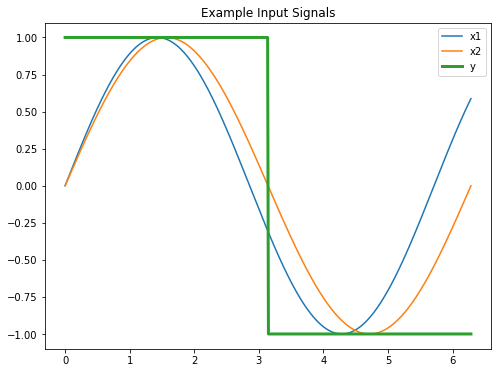

In [3]:
n_samples = 500
t = np.linspace(0, 2*np.pi, n_samples)
omega1 = 1.1
omega2 = 1

x1 = np.sin(omega1*t)
x2 = np.sin(omega2*t)

x = np.hstack(
    (x1.reshape(-1, 1), x2.reshape(-1, 1)))

y = -2*(np.heaviside(t - np.pi, 0.5) - 0.5)

fig, axs = plt.subplots(figsize=(8,6))
axs.plot(t, x)
axs.plot(t, y, linewidth=3)
axs.set_title('Example Input Signals')
axs.legend(('x1', 'x2', 'y'))

## Instantiate the Neural Net

In [4]:
ffnn = FFNN(
    net_type='relu',
    n_inputs=2, n_hidden=50,
    lr=0.05, momentum=0.1,
    use_gpu=True)
    

## Fit the neural network

In [5]:
# Finish fit - fit a function
ffnn.fit(x, y, n_epochs=200)


Fitting using device: cuda:0
[1] loss: 1.028887
[2] loss: 1.003342
[3] loss: 1.013160
[4] loss: 1.041747
[5] loss: 1.021912
[6] loss: 1.001252
[7] loss: 1.037118
[8] loss: 1.050810
[9] loss: 1.008751
[10] loss: 1.014900
[11] loss: 1.066474
[12] loss: 1.045340
[13] loss: 1.000403
[14] loss: 1.047305
[15] loss: 1.089221
[16] loss: 1.029338
[17] loss: 1.007867
[18] loss: 1.089787
[19] loss: 1.099426
[20] loss: 1.013324
[21] loss: 1.030778
[22] loss: 1.131530
[23] loss: 1.104385
[24] loss: 1.005830
[25] loss: 1.053753
[26] loss: 1.166711
[27] loss: 1.119851
[28] loss: 1.006583
[29] loss: 1.056743
[30] loss: 1.188668
[31] loss: 1.165521
[32] loss: 1.030293
[33] loss: 1.021162
[34] loss: 1.159481
[35] loss: 1.226470
[36] loss: 1.122449
[37] loss: 1.007531
[38] loss: 1.041166
[39] loss: 1.171556
[40] loss: 1.234190
[41] loss: 1.162612
[42] loss: 1.044635
[43] loss: 1.001023
[44] loss: 1.063326
[45] loss: 1.165169
[46] loss: 1.217340
[47] loss: 1.183405
[48] loss: 1.097048
[49] loss: 1.022015


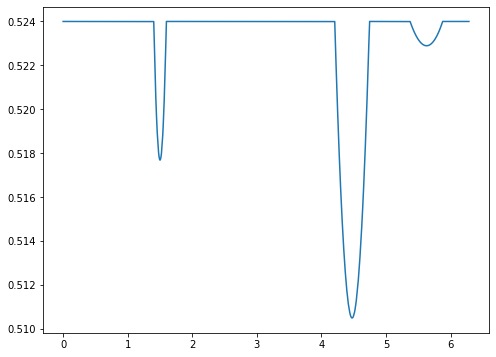

In [6]:
# Use the infer interface to rapidly get results for slightly different signals
n_samples = 1000000
t = np.linspace(0, 2*np.pi, n_samples)
omega1 = 1.11
omega2 = 0.99

x1 = np.sin(omega1*t)
x2 = np.sin(omega2*t)

x = np.hstack(
    (x1.reshape(-1, 1), x2.reshape(-1, 1)))

y = -2*(np.heaviside(t - np.pi, 0.5) - 0.5)

y_net = ffnn.infer(x)

fig, axs = plt.subplots(figsize=(8, 6))
axs.plot(t, y_net)
